# Data Processing

This part will handle missing values.
1. We dropped the column of "NMHC(GT)" as over 90% of its data is missing. 
2. We filled missing data with average values. We then standardized the data with Z-Score.
3. We added 12 extra columns recording whether the data missed or not in the original data.

In [22]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    silhouette_score, calinski_harabasz_score, davies_bouldin_score
)
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings, random

warnings.filterwarnings("ignore")
SEED = 114514
def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
set_seed(SEED)

In [ ]:
set_seed(SEED)
df = pd.read_csv(
    "./AirQualityUCI.csv", 
    sep=";", 
    na_values=["", "-200"], 
    keep_default_na=False
)
# Dropping empty rows und columns
df = df.dropna(axis=1, how="all")
df = df.dropna(axis=0, how="all")
print(f"Size: {len(df)}")

missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100
missing_info = pd.DataFrame({
    "Null Amount": missing_count,
    "Null Percentage": missing_percent.round(2)
})
print(missing_info[missing_info["Null Amount"] > 0])

if "NMHC(GT)" in df.columns: del df["NMHC(GT)"] # It is a 90%+ missing column, so we just delete it.

missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100
missing_info = pd.DataFrame({
    "Null Amount": missing_count,
    "Null Percentage": missing_percent.round(2)
})
print("\nNMHC(GT) Dropped\n")
print(missing_info[missing_info["Null Amount"] > 0])

# Changing the ,s into .s.
for col in df.columns:
    if col not in ["Date", "Time"]:
        try: df[col] = df[col].str.replace(",", ".").astype(float)
        except (AttributeError, ValueError): pass

# Filling nulls by avr
for col in df.columns:
    if col not in ["Date", "Time"]:
        df[f"{col}_missing"] = df[col].isnull().astype(int)
        df[col] = df[col].fillna(df[col].mean())

# clipping outliers to IQR boundaries

numeric_cols = [col for col in df.columns 
                if not (col in ["Date", "Time"] or col.endswith("_missing"))]

affected_counts = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    too_low  = df[col] < lower_bound
    too_high = df[col] > upper_bound
    n_low  = too_low.sum()
    n_high = too_high.sum()
    
    if n_low + n_high > 0:
        affected_counts[col] = (n_low, n_high, lower_bound, upper_bound)
        print(f"  {col:18} → clipped {n_low:4} low values to {lower_bound:.3f} | "
              f"{n_high:4} high values to {upper_bound:.3f}")

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    
total_clipped = sum(low + high for low, high, _, _ in affected_counts.values())
print(f"\nTotal values clipped: {total_clipped} (across all columns)")
print(f"Rows remain unchanged: {len(df)}\n")

# Z-score
numeric_cols = [col for col in df.columns if not (col in ["Date", "Time"] or col.endswith("_missing"))]
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.to_csv("./AirQuality_processed.csv", index=False)
print(f"\nProcessed data: size: {len(df)} columns: {len(df.columns)}")
print(f"\nHead: \n{df.head()}")

Size: 9357
               Null Amount  Null Percentage
CO(GT)                1592            17.01
PT08.S1(CO)            366             3.91
NMHC(GT)              8443            90.23
PT08.S2(NMHC)          366             3.91
NOx(GT)               1639            17.52
PT08.S3(NOx)           366             3.91
NO2(GT)               1642            17.55
PT08.S4(NO2)           366             3.91
PT08.S5(O3)            366             3.91
T                      366             3.91
RH                     366             3.91
AH                     366             3.91

NMHC(GT) Dropped

               Null Amount  Null Percentage
CO(GT)                1592            17.01
PT08.S1(CO)            366             3.91
PT08.S2(NMHC)          366             3.91
NOx(GT)               1639            17.52
PT08.S3(NOx)           366             3.91
NO2(GT)               1642            17.55
PT08.S4(NO2)           366             3.91
PT08.S5(O3)            366             3.91
T 

# Visualization (t-SNE)

We did the thing in both 2d and 3d, containing and not containing the missing columns.

In [ ]:
set_seed(SEED)
# t-SNE with the missing columns
def tsne_visualization(tsne_features, df, name=""):
    tsne_2d = TSNE(
        n_components=2,
        perplexity=30,
        random_state=SEED,
        n_iter=1000
    )
    tsne_2d_result = tsne_2d.fit_transform(tsne_features)

    tsne_3d = TSNE(
        n_components=3,
        perplexity=30,
        random_state=SEED,
        n_iter=1000
    )
    tsne_3d_result = tsne_3d.fit_transform(tsne_features)

    plt.figure(figsize=(10, 7))
    colors = {"Morning (0-8)": "#FF6B6B", "Afternoon (9-16)": "#4ECDC4", "Evening (17-23)": "#45B7D1"}
    markers = {"Morning (0-8)": "o", "Afternoon (9-16)": "s", "Evening (17-23)": "^"}
    if "Low CO" in df['Time_Label'].unique():
        colors = {"Low CO": "#90EE90", "Medium CO": "#FFD700", "High CO": "#FF6347"}
        markers = {"Low CO": "o", "Medium CO": "s", "High CO": "^"}

    for label in df['Time_Label'].dropna().unique():
        mask = df['Time_Label'] == label
        plt.scatter(
            tsne_2d_result[mask, 0],
            tsne_2d_result[mask, 1],
            c=colors[label],
            marker=markers[label],
            label=label,
            alpha=0.7, 
            s=60 
        )

    plt.title("t-SNE 2D Visualization of Air Quality Data", fontsize=14, fontweight="bold")
    plt.xlabel("t-SNE Dimension 1", fontsize=12)
    plt.ylabel("t-SNE Dimension 2", fontsize=12)
    plt.legend(loc="best", fontsize=10)
    plt.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.savefig(f"tsne_2d_air_quality_{name}.png", dpi=300, bbox_inches="tight") 
    plt.show()

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")

    for label in df['Time_Label'].dropna().unique():
        mask = df['Time_Label'] == label
        ax.scatter(
            tsne_3d_result[mask, 0],
            tsne_3d_result[mask, 1],
            tsne_3d_result[mask, 2],
            c=colors[label],
            marker=markers[label],
            label=label,
            alpha=0.7,
            s=60
        )

    ax.set_title("t-SNE 3D Visualization of Air Quality Data", fontsize=14, fontweight="bold", y=1.02)
    ax.set_xlabel("t-SNE Dimension 1", fontsize=12, labelpad=10)
    ax.set_ylabel("t-SNE Dimension 2", fontsize=12, labelpad=10)
    ax.set_zlabel("t-SNE Dimension 3", fontsize=12, labelpad=10)

    ax.legend(
        loc="center left", 
        bbox_to_anchor=(1.05, 0.5), 
        fontsize=10,
        frameon=False
    )

    plt.subplots_adjust(right=0.8)
    plt.tight_layout()
    plt.savefig(f"tsne_3d_air_quality{name}.png", dpi=300, bbox_inches="tight")
    plt.show()


With the missing columns



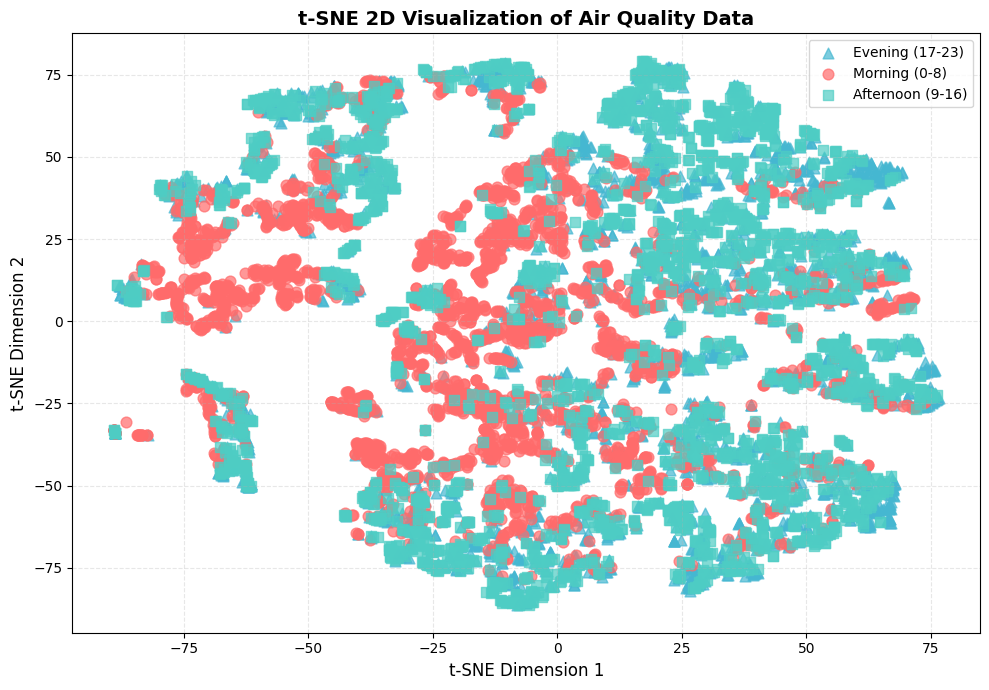

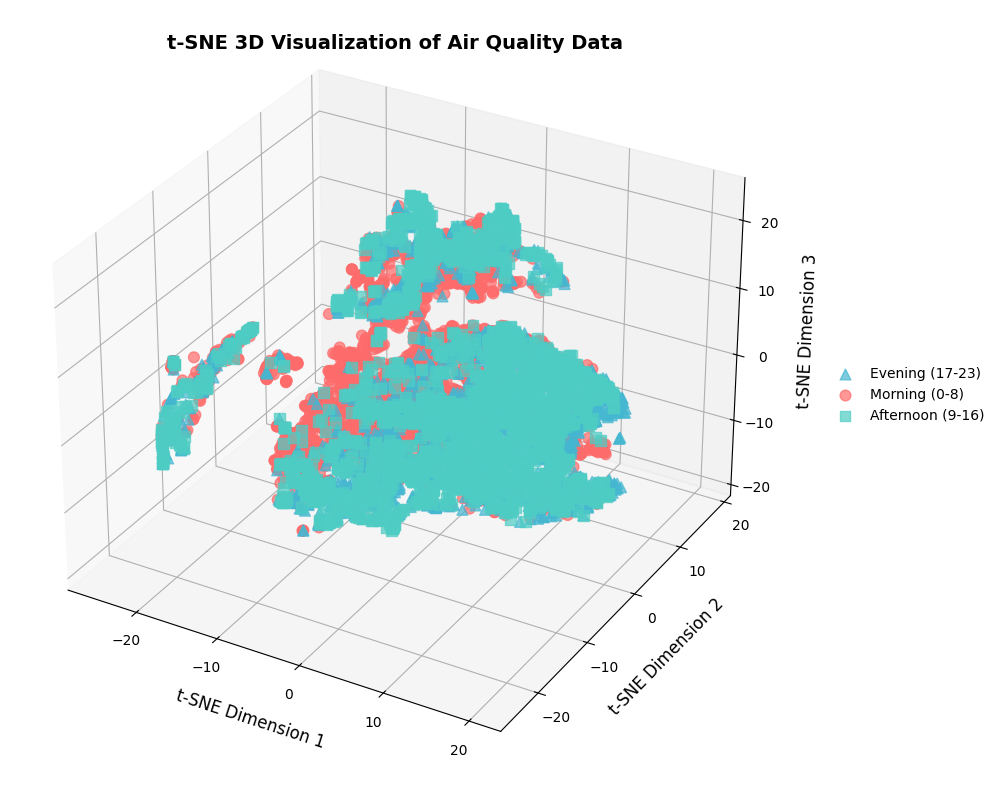


Without the missing columns



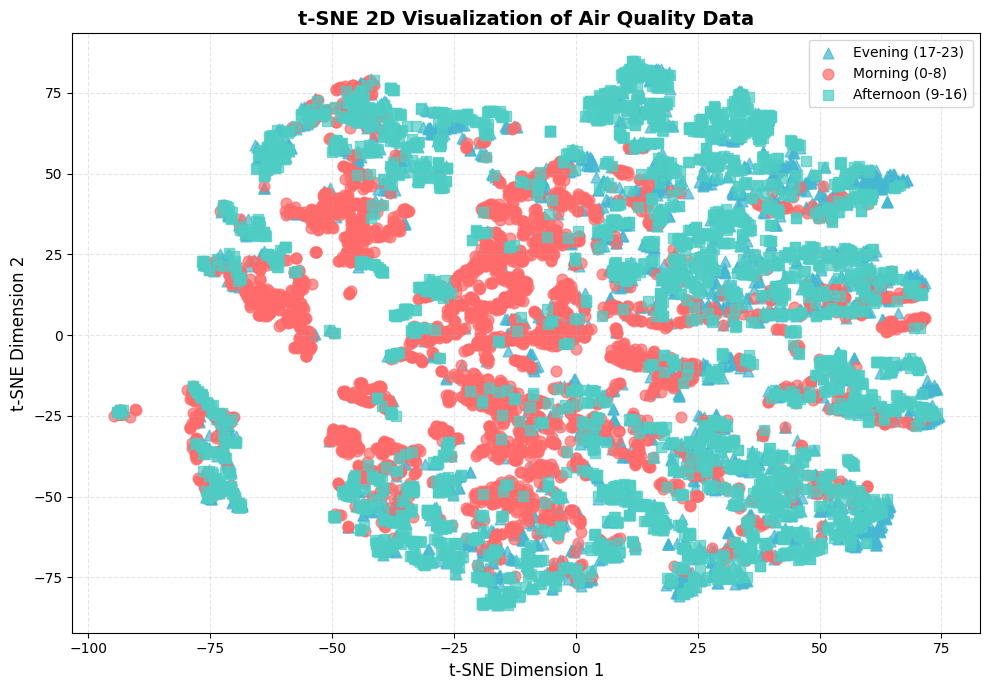

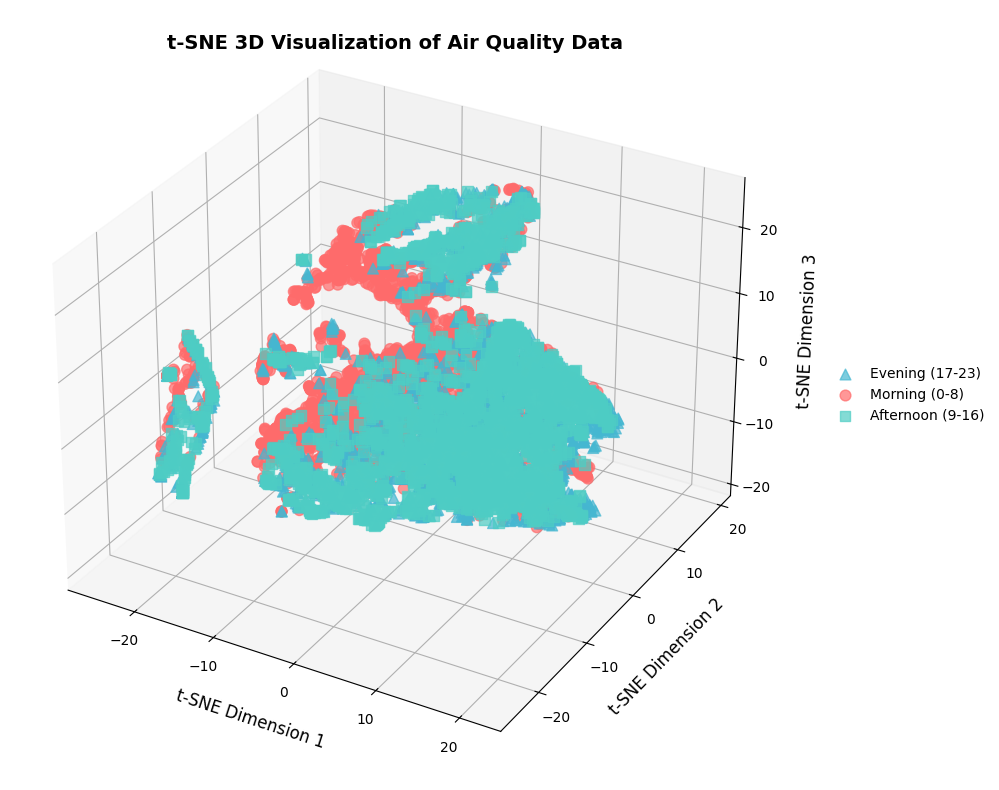

In [ ]:
set_seed(SEED)
df = pd.read_csv("./AirQuality_processed.csv")

if "Time" in df.columns:
    df['Hour'] = pd.to_datetime(df['Time'].str.replace(".", ":"), format="%H:%M:%S", errors="coerce").dt.hour
    df['Time_Label'] = pd.cut(
        df['Hour'],
        bins=[0, 8, 16, 23],
        labels=["Morning (0-8)", "Afternoon (9-16)", "Evening (17-23)"]
    )
else: df['Time_Label'] = pd.cut(
        df['CO(GT)'],
        bins=[0, 2, 5, 10],
        labels=['Low CO", "Medium CO", "High CO']
    )

exclude_cols = ["Date", "Time", "Hour", "Time_Label"]
tsne_features = df.drop([col for col in exclude_cols if col in df.columns], axis=1)
print("="*60)
print("\nWith the missing columns\n")
tsne_visualization(tsne_features, df, "with_missing")

exclude_cols = ["Date", "Time", "Hour", "Time_Label"]
tsne_features = df.drop([col for col in df.columns if col in exclude_cols or col.endswith("_missing")], axis=1)
print("="*60)
print("\nWithout the missing columns\n")
tsne_visualization(tsne_features, df, "without_missing")

# Clustering 

We would try both K-means and Hierarchical clustering, and evaluate them.

Clustering: 12 columns
Samples: 9357 rows
k=2 | Inertia=72918.20 | sil_score=0.3109
k=3 | Inertia=60622.76 | sil_score=0.2222
k=4 | Inertia=52387.44 | sil_score=0.2198
k=5 | Inertia=47138.50 | sil_score=0.2008
k=6 | Inertia=43378.16 | sil_score=0.1953
k=7 | Inertia=41015.54 | sil_score=0.1806
k=8 | Inertia=38272.83 | sil_score=0.1848
k=9 | Inertia=37281.79 | sil_score=0.1748
k=10 | Inertia=35174.59 | sil_score=0.1766
k=11 | Inertia=34050.57 | sil_score=0.1824
k=12 | Inertia=32426.54 | sil_score=0.1796
k=13 | Inertia=31537.04 | sil_score=0.1726
k=14 | Inertia=30308.19 | sil_score=0.1802
k=15 | Inertia=29425.38 | sil_score=0.1759
k=16 | Inertia=27779.28 | sil_score=0.1901
k=17 | Inertia=26951.91 | sil_score=0.1986
k=18 | Inertia=26084.52 | sil_score=0.2016
k=19 | Inertia=25422.20 | sil_score=0.2002
k=20 | Inertia=24874.25 | sil_score=0.2010


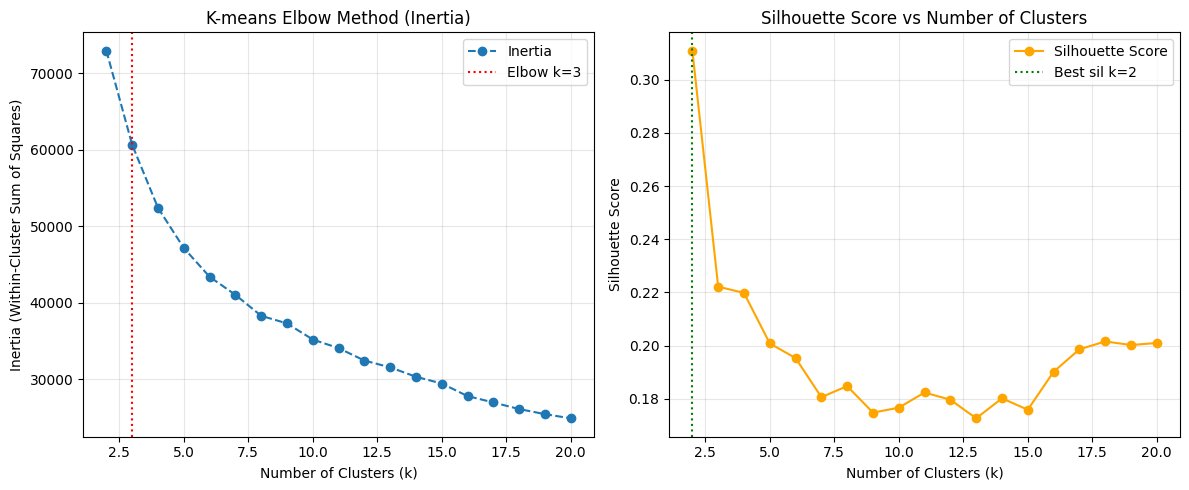


Optimal k by elbow: 3
Optimal k by silhouette score: 2


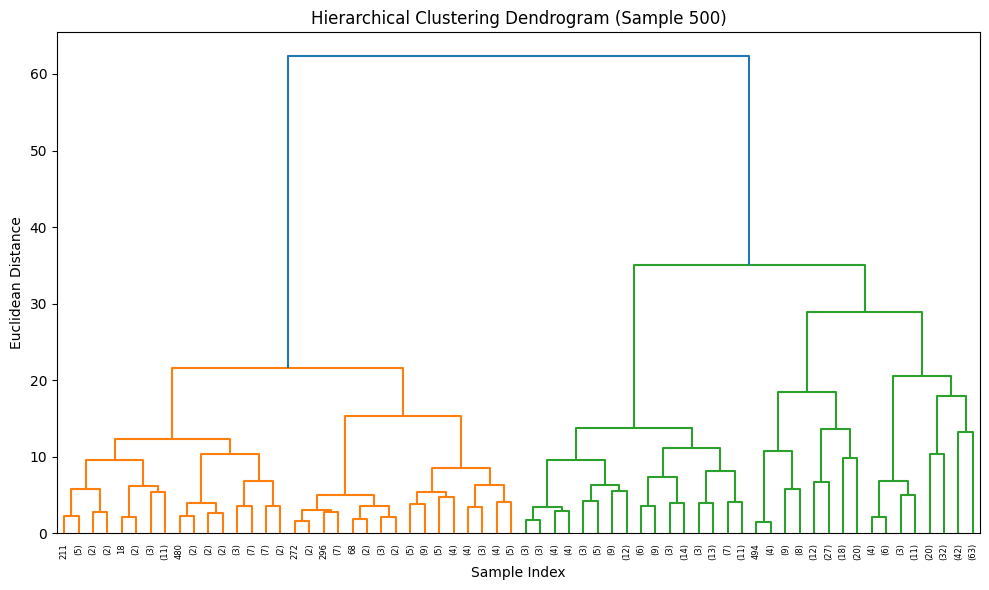


=== K-means Evaluation ===
Silhouette Score: 0.2222
Calinski-Harabasz Score: 3985.6372
Davies-Bouldin Score: 1.4969

=== Hierarchical Evaluation ===
Silhouette Score: 0.1468
Calinski-Harabasz Score: 3105.1296
Davies-Bouldin Score: 1.8756

Evaluation of Clustering:
                    Metric      K-means  Hierarchical
0         Silhouette Score     0.222177      0.146847
1  Calinski-Harabasz Score  3985.637249   3105.129622
2     Davies-Bouldin Score     1.496935      1.875648


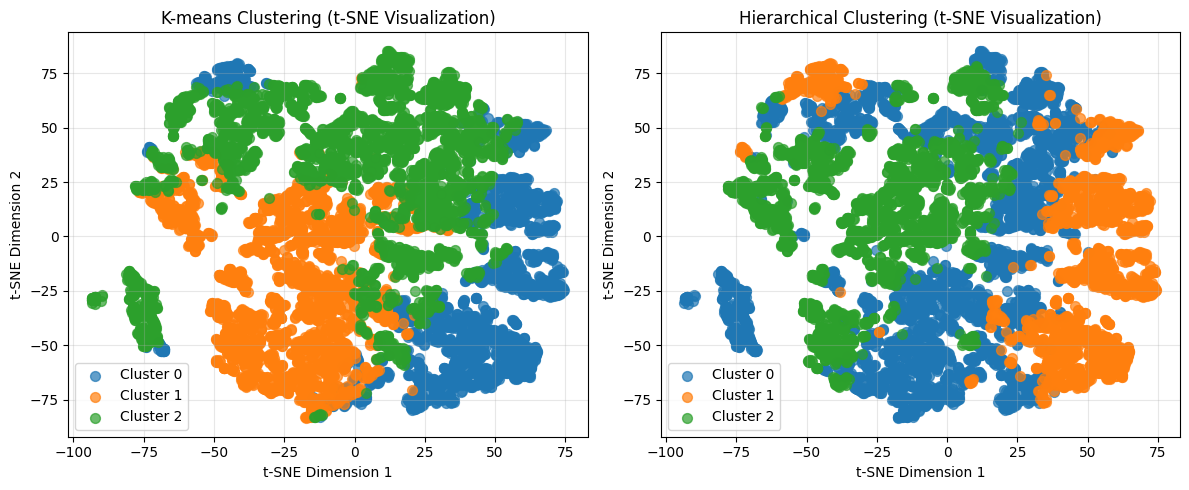

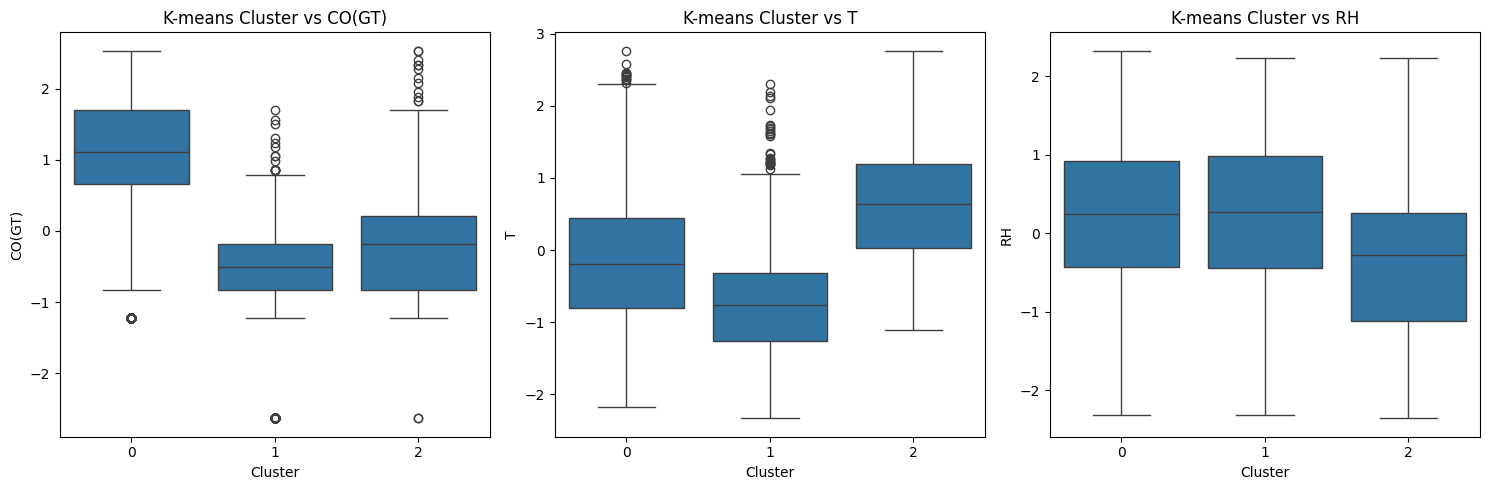

Better algorithm: K-means
This is because:
1. Silhouette Score: K-means (0.2222) > Hierarchical Clustering (0.1468), indicating that K-means clustering has better sample cohesion and separation;
2. CH Score: K-means (3985.6372) > Hierarchical Clustering (3105.1296), indicating that K-means has larger inter-cluster differences and smaller intra-cluster differences;
3. DB Score: K-means (1.4969) < Hierarchical Clustering (1.8756), indicating that K-means clustering results are more compact with less inter-cluster overlap;



In [ ]:
set_seed(SEED)
df = pd.read_csv('./AirQuality_processed.csv')

exclude_cols = ['Date', 'Time', 'Hour', 'Time_Label']
cluster_features = df[
    [col for col in df.columns if col not in exclude_cols and not col.endswith("_missing")]
]

scaler = StandardScaler()
cluster_features_scaled = scaler.fit_transform(cluster_features)

print(f"Clustering: {cluster_features_scaled.shape[1]} columns")
print(f"Samples: {cluster_features_scaled.shape[0]} rows")

# finding best k
def find_optimal_k(data, max_k=20, min_k=2):
    inertia = [] 
    silhouette_scores = [] 

    for k in range(min_k, max_k+1):
        kmeans = KMeans(n_clusters=k, random_state=SEED, n_init='auto') 
        labels = kmeans.fit_predict(data)
        inertia.append(kmeans.inertia_)
        sil_score = silhouette_score(data, labels)
        silhouette_scores.append(sil_score)
        print(f"k={k} | Inertia={inertia[-1]:.2f} | sil_score={sil_score:.4f}")

    first_derivative = np.diff(inertia)
    second_derivative = np.diff(first_derivative)
    elbow_k = min_k + np.argmax(second_derivative) + 1 

    best_sil_k = min_k + np.argmax(silhouette_scores)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(min_k, max_k+1), inertia, marker='o', linestyle='--', label='Inertia')
    plt.axvline(x=elbow_k, color='red', linestyle=':', label=f'Elbow k={elbow_k}')
    plt.title('K-means Elbow Method (Inertia)', fontsize=12)
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
    plt.grid(alpha=0.3)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(min_k, max_k+1), silhouette_scores, marker='o', color='orange', label='Silhouette Score')
    plt.axvline(x=best_sil_k, color='green', linestyle=':', label=f'Best sil k={best_sil_k}')
    plt.title('Silhouette Score vs Number of Clusters', fontsize=12)
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig('optimal_k_detection.png', dpi=300)
    plt.show()

    print(f"\nOptimal k by elbow: {elbow_k}")
    print(f"Optimal k by silhouette score: {best_sil_k}")

    return elbow_k 
    # return best_sil_k

optimal_k = find_optimal_k(cluster_features_scaled, max_k=20)

# k-means
kmeans = KMeans(n_clusters=optimal_k, random_state=SEED)
kmeans_labels = kmeans.fit_predict(cluster_features_scaled)
df['KMeans_Cluster'] = kmeans_labels

hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(cluster_features_scaled)
df['Hierarchical_Cluster'] = hierarchical_labels

# tree-like graph of hierarchical clustering
plt.figure(figsize=(10, 6))
sample_idx = np.random.choice(len(cluster_features_scaled), 500, replace=False)
linkage_matrix = linkage(cluster_features_scaled[sample_idx], method='ward')
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram (Sample 500)', fontsize=12)
plt.xlabel('Sample Index')
plt.ylabel('Euclidean Distance')
plt.tight_layout()
plt.savefig('hierarchical_dendrogram.png', dpi=300)
plt.show()

# evaluate clustering
def evaluate_clustering(data, labels, algorithm_name):
    metrics = {
        'Silhouette Score': silhouette_score(data, labels),
        'Calinski-Harabasz Score': calinski_harabasz_score(data, labels),
        'Davies-Bouldin Score': davies_bouldin_score(data, labels)
    }
    print(f"\n=== {algorithm_name} Evaluation ===")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
    return metrics

kmeans_metrics = evaluate_clustering(cluster_features_scaled, kmeans_labels, 'K-means')
hierarchical_metrics = evaluate_clustering(cluster_features_scaled, hierarchical_labels, 'Hierarchical')

metrics_df = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Calinski-Harabasz Score', 'Davies-Bouldin Score'],
    'K-means': [kmeans_metrics['Silhouette Score'], kmeans_metrics['Calinski-Harabasz Score'], kmeans_metrics['Davies-Bouldin Score']],
    'Hierarchical': [hierarchical_metrics['Silhouette Score'], hierarchical_metrics['Calinski-Harabasz Score'], hierarchical_metrics['Davies-Bouldin Score']]
})
print("\nEvaluation of Clustering:")
print(metrics_df)

# t-SNE
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
tsne_result = tsne.fit_transform(cluster_features_scaled)
df['TSNE_1'] = tsne_result[:, 0]
df['TSNE_2'] = tsne_result[:, 1]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for cluster in range(optimal_k):
    mask = df['KMeans_Cluster'] == cluster
    plt.scatter(df.loc[mask, 'TSNE_1'], df.loc[mask, 'TSNE_2'], label=f'Cluster {cluster}', alpha=0.7, s=50)
plt.title('K-means Clustering (t-SNE Visualization)', fontsize=12)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
for cluster in range(optimal_k):
    mask = df['Hierarchical_Cluster'] == cluster
    plt.scatter(df.loc[mask, 'TSNE_1'], df.loc[mask, 'TSNE_2'], label=f'Cluster {cluster}', alpha=0.7, s=50)
plt.title('Hierarchical Clustering (t-SNE Visualization)', fontsize=12)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('clustering_visualization.png', dpi=300)
plt.show()

core_features = ['CO(GT)', 'T', 'RH']
plt.figure(figsize=(15, 5))
for i, feature in enumerate(core_features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='KMeans_Cluster', y=feature, data=df)
    plt.title(f'K-means Cluster vs {feature}', fontsize=12)
    plt.xlabel('Cluster')
    plt.ylabel(feature)
plt.tight_layout()
plt.savefig('cluster_feature_distribution.png', dpi=300)
plt.show()

if (kmeans_metrics['Silhouette Score'] > hierarchical_metrics['Silhouette Score'] and
    kmeans_metrics['Calinski-Harabasz Score'] > hierarchical_metrics['Calinski-Harabasz Score'] and
    kmeans_metrics['Davies-Bouldin Score'] < hierarchical_metrics['Davies-Bouldin Score']):
    best_algorithm = 'K-means'
    justification = (
        f"1. Silhouette Score: K-means ({kmeans_metrics['Silhouette Score']:.4f}) > Hierarchical Clustering ({hierarchical_metrics['Silhouette Score']:.4f}), indicating that K-means clustering has better sample cohesion and separation;\n"
        f"2. CH Score: K-means ({kmeans_metrics['Calinski-Harabasz Score']:.4f}) > Hierarchical Clustering ({hierarchical_metrics['Calinski-Harabasz Score']:.4f}), indicating that K-means has larger inter-cluster differences and smaller intra-cluster differences;\n"
        f"3. DB Score: K-means ({kmeans_metrics['Davies-Bouldin Score']:.4f}) < Hierarchical Clustering ({hierarchical_metrics['Davies-Bouldin Score']:.4f}), indicating that K-means clustering results are more compact with less inter-cluster overlap;\n"
    )
else:
    best_algorithm = 'Hierarchical Clustering'
    justification = (
        f"1. Silhouette Score: Hierarchical Clustering ({hierarchical_metrics['Silhouette Score']:.4f}) > K-means ({kmeans_metrics['Silhouette Score']:.4f}), indicating that Hierarchical Clustering has better sample cohesion and separation;\n"
        f"2. CH Score: Hierarchical Clustering ({hierarchical_metrics['Calinski-Harabasz Score']:.4f}) > K-means ({kmeans_metrics['Calinski-Harabasz Score']:.4f}), indicating that Hierarchical Clustering has larger inter-cluster differences and smaller intra-cluster differences;\n"
        f"3. DB Score: Hierarchical Clustering ({hierarchical_metrics['Davies-Bouldin Score']:.4f}) < K-means ({kmeans_metrics['Davies-Bouldin Score']:.4f}), indicating that Hierarchical Clustering results are more compact with less inter-cluster overlap;\n"
    )

print(f"Better algorithm: {best_algorithm}")
print("This is because:")
print(justification)

df.to_csv('./AirQuality_with_clusters.csv', index=False)

# Basic Prediction & Model Evaluation and Improvements  
We tried a prediction on whether the CO level is exceeding normal level.  
We used logistic regression and decision tree.  

After that, We would improve Logistic Regression by using polynomial degree of 2. We would improve the Decision Tree by adding depth.

Model: Logistic Regression


===== Training Set =====
Confusion Matrix:
[[3079  517]
 [ 618 2335]]
Accuracy:     0.8267
Precision:    0.8187
Recall:       0.7907
F1-Score:     0.8045
AUC Score:    0.9109


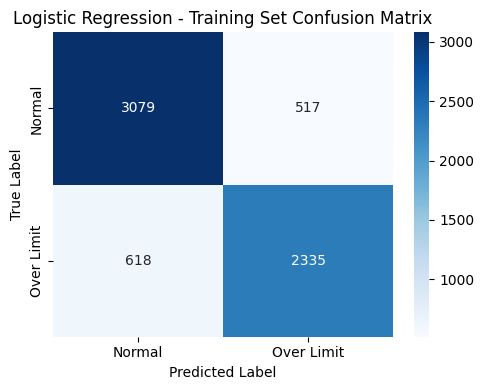


===== Testing Set =====
Confusion Matrix:
[[1333  204]
 [ 284  987]]
Accuracy:     0.8262
Precision:    0.8287
Recall:       0.7766
F1-Score:     0.8018
AUC Score:    0.9147


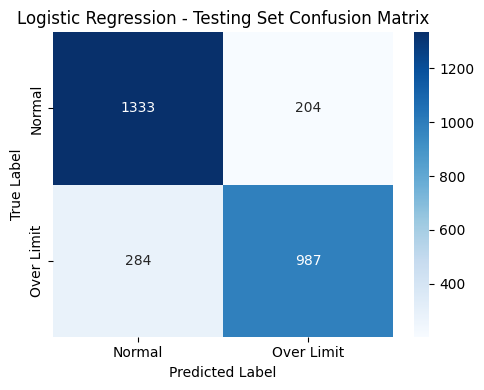


===== Entire Dataset =====
Confusion Matrix:
[[4412  721]
 [ 902 3322]]
Accuracy:     0.8265
Precision:    0.8217
Recall:       0.7865
F1-Score:     0.8037
AUC Score:    0.9120


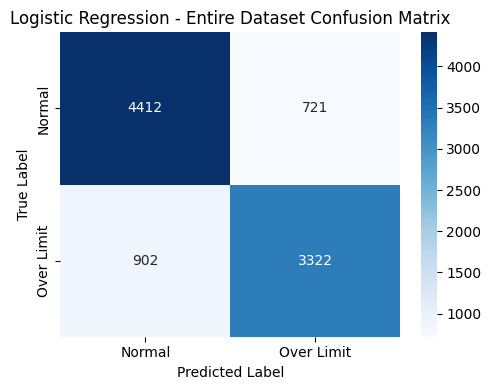

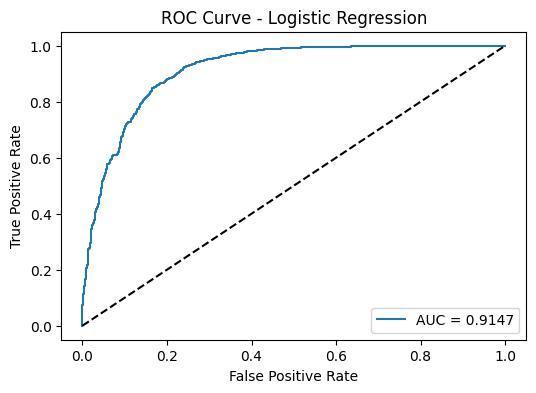


5-fold CV Accuracy: 0.7702 ± 0.0601



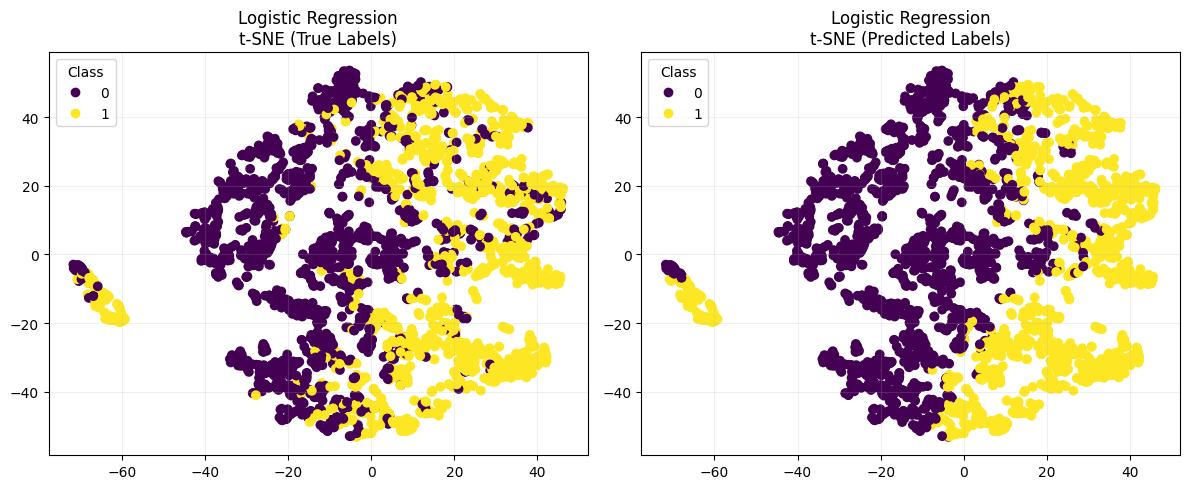

Model: Decision Tree


===== Training Set =====
Confusion Matrix:
[[3175  421]
 [ 260 2693]]
Accuracy:     0.8960
Precision:    0.8648
Recall:       0.9120
F1-Score:     0.8878
AUC Score:    0.9401


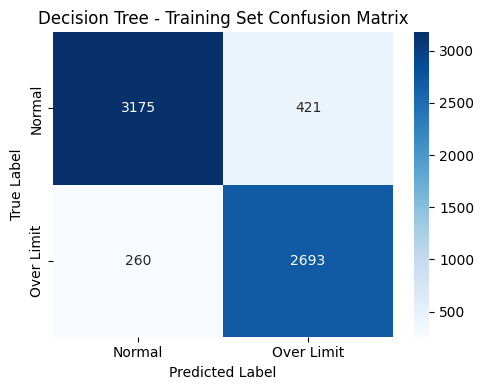


===== Testing Set =====
Confusion Matrix:
[[1351  186]
 [ 111 1160]]
Accuracy:     0.8942
Precision:    0.8618
Recall:       0.9127
F1-Score:     0.8865
AUC Score:    0.9362


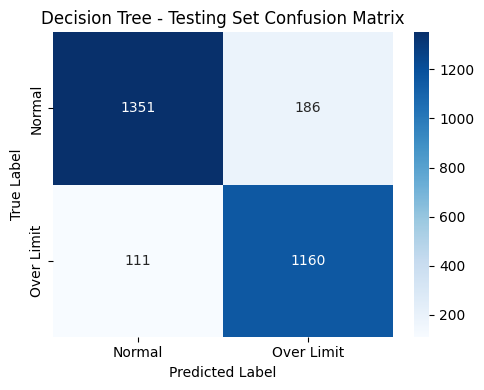


===== Entire Dataset =====
Confusion Matrix:
[[4526  607]
 [ 371 3853]]
Accuracy:     0.8955
Precision:    0.8639
Recall:       0.9122
F1-Score:     0.8874
AUC Score:    0.9390


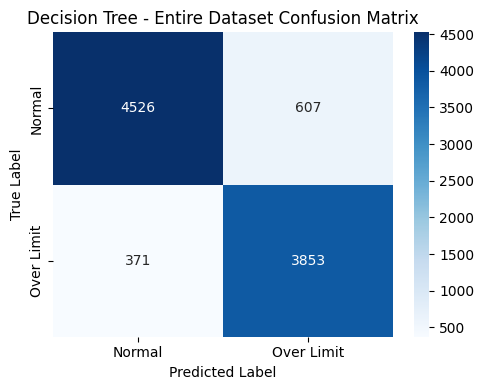

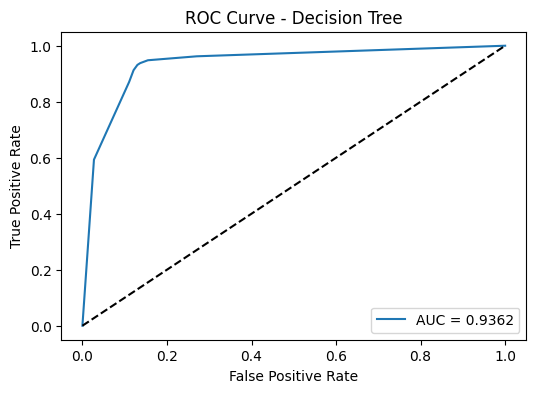


5-fold CV Accuracy: 0.8845 ± 0.0452



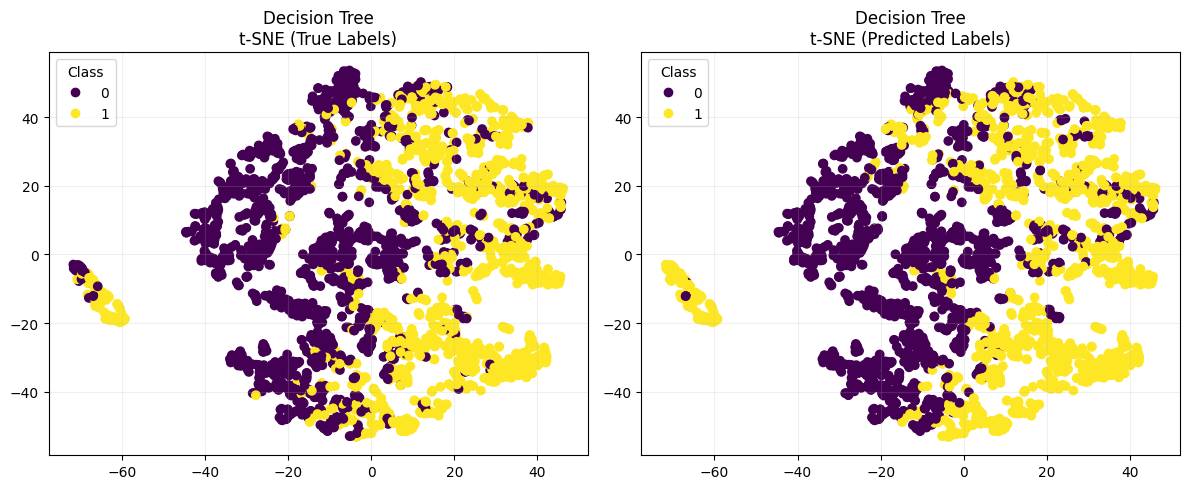

In [23]:
set_seed(SEED)
df = pd.read_csv("./AirQuality_processed.csv")
df["CO_over_limit"] = (df["CO(GT)"] > 0).astype(int)

feature_cols = ["PT08.S1(CO)", "C6H6(GT)", "PT08.S2(NMHC)", "NOx(GT)", "PT08.S3(NOx)", "NO2(GT)", "PT08.S4(NO2)", "PT08.S5(O3)", "T", "RH", "AH"]
df = df.dropna(subset=feature_cols + ["CO_over_limit"])
X = df[feature_cols]
y = df["CO_over_limit"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=SEED)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=SEED)
}

def evaluate_model(name, model, X_data, y_true, dataset_name):
    y_pred = model.predict(X_data)
    y_pred_proba = model.predict_proba(X_data)[:, 1]

    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_pred_proba)

    print(f"\n===== {dataset_name} =====")
    print(f"Confusion Matrix:\n{cm}")
    print(f"Accuracy:     {acc:.4f}")
    print(f"Precision:    {precision:.4f}")
    print(f"Recall:       {recall:.4f}")
    print(f"F1-Score:     {f1:.4f}")
    print(f"AUC Score:    {auc:.4f}")

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Over Limit"], yticklabels=["Normal", "Over Limit"])
    plt.title(f"{name} - {dataset_name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    return y_pred, auc

for name, model in models.items():
    print("=" * 80)
    print(f"Model: {name}\n")

    model.fit(X_train, y_train)

    evaluate_model(name, model, X_train, y_train, "Training Set")
    y_pred_test, auc_test = evaluate_model(name, model, X_test, y_test, "Testing Set")
    evaluate_model(name, model, X_scaled, y, "Entire Dataset")

    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"AUC = {auc_test:.4f}")
    plt.plot([0,1],[0,1],"k--")
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring="accuracy")
    print(f"\n5-fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}\n")

    tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
    X_test_tsne = tsne.fit_transform(X_test)

    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
    ax1.scatter(X_test_tsne[:,0], X_test_tsne[:,1], c=y_test, cmap="coolwarm", alpha=0.6, s=15)
    ax1.set_title(f"{name}\nt-SNE (True Labels)")
    ax1.legend(*ax1.scatter(X_test_tsne[:,0], X_test_tsne[:,1], c=y_test).legend_elements(), title="Class")
    ax1.grid(alpha=0.2)

    ax2.scatter(X_test_tsne[:,0], X_test_tsne[:,1], c=y_pred_test, cmap="coolwarm", alpha=0.6, s=15)
    ax2.set_title(f"{name}\nt-SNE (Predicted Labels)")
    ax2.legend(*ax2.scatter(X_test_tsne[:,0], X_test_tsne[:,1], c=y_pred_test).legend_elements(), title="Class")
    ax2.grid(alpha=0.2)
    
    plt.tight_layout()
    plt.show()

Logistic Regression + Polynomial Features

===== Train Set =====
Confusion Matrix:
[[3242  354]
 [ 393 2560]]
Accuracy:  0.8859
Precision: 0.8785
Recall:    0.8669
F1:        0.8727
AUC:       0.9557


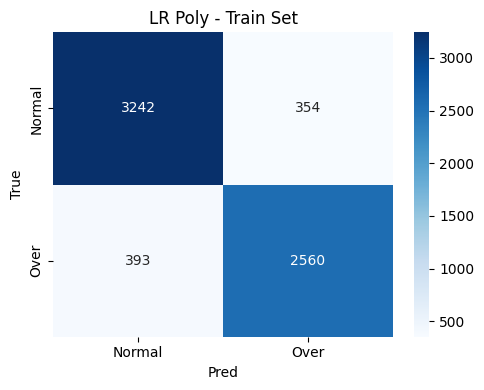


===== Test Set =====
Confusion Matrix:
[[1386  151]
 [ 179 1092]]
Accuracy:  0.8825
Precision: 0.8785
Recall:    0.8592
F1:        0.8687
AUC:       0.9533


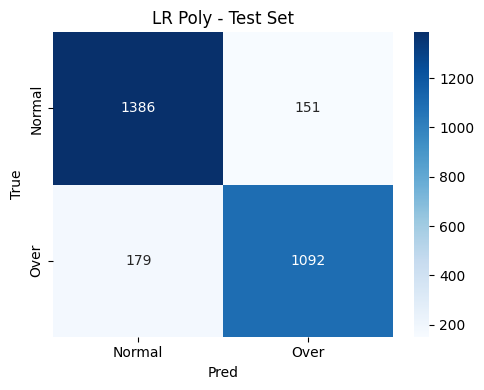


===== Full Set =====
Confusion Matrix:
[[4628  505]
 [ 572 3652]]
Accuracy:  0.8849
Precision: 0.8785
Recall:    0.8646
F1:        0.8715
AUC:       0.9550


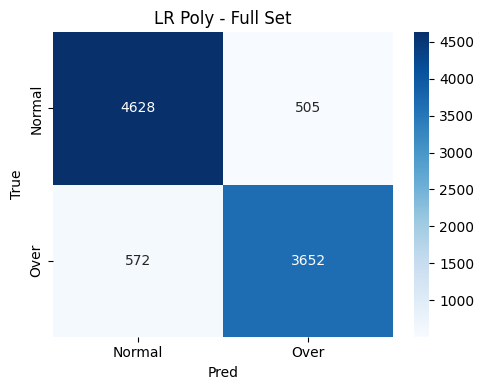

CV Acc: 0.7986 ± 0.0355



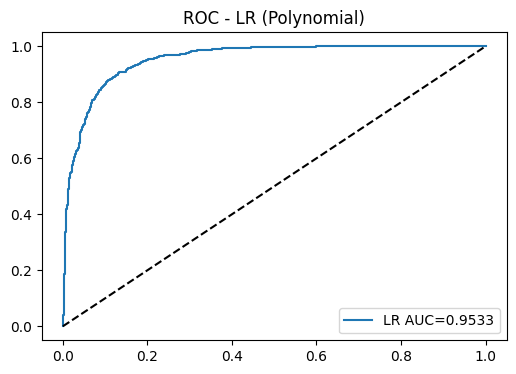

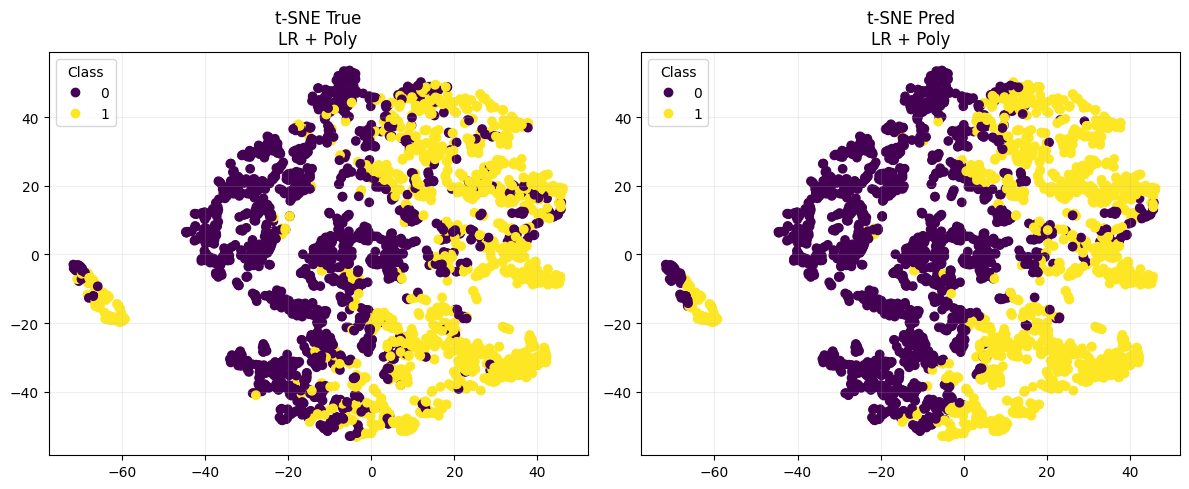

Decision Tree (Tuned max_depth)
Best max_depth = 5

===== Train Set =====
Confusion Matrix:
[[3317  279]
 [ 255 2698]]
Accuracy:  0.9185
Precision: 0.9063
Recall:    0.9136
F1:        0.9099
AUC:       0.9635


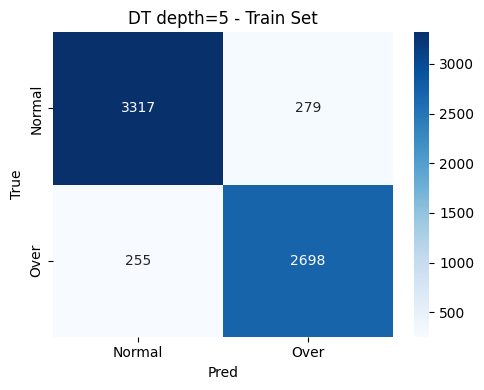


===== Test Set =====
Confusion Matrix:
[[1411  126]
 [ 121 1150]]
Accuracy:  0.9120
Precision: 0.9013
Recall:    0.9048
F1:        0.9030
AUC:       0.9535


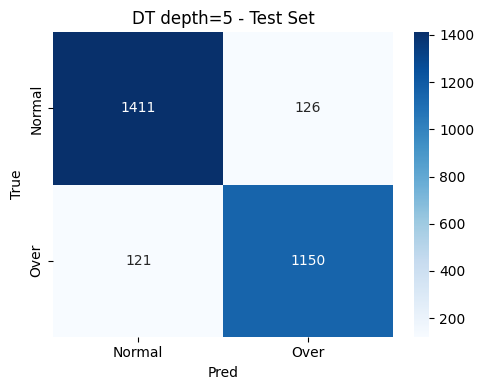


===== Full Set =====
Confusion Matrix:
[[4728  405]
 [ 376 3848]]
Accuracy:  0.9165
Precision: 0.9048
Recall:    0.9110
F1:        0.9079
AUC:       0.9605


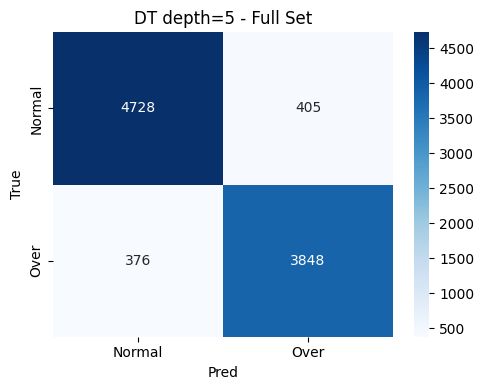

CV Acc: 0.8850 ± 0.0285



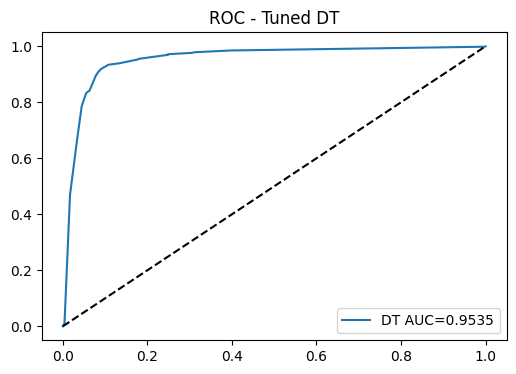

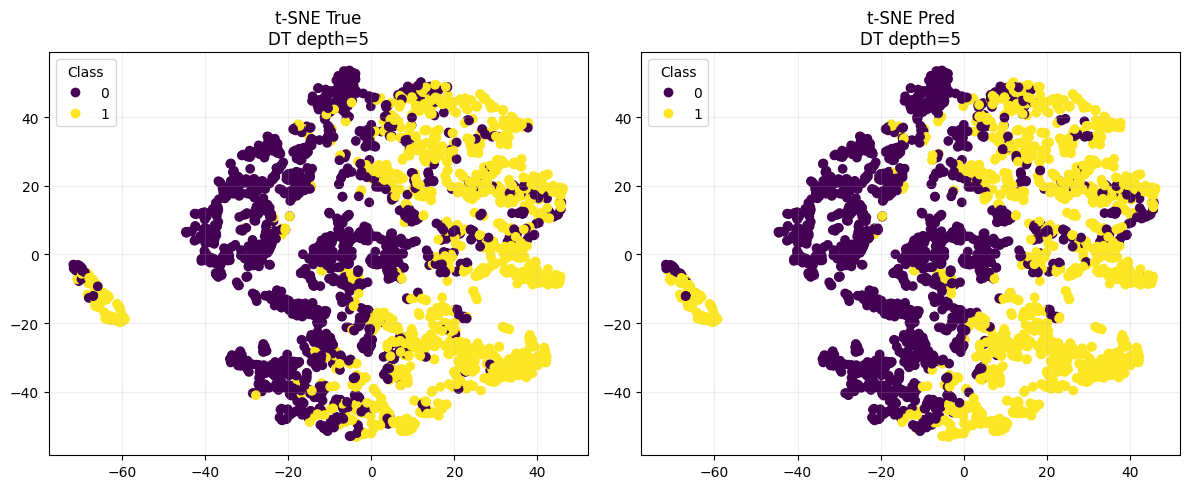

In [24]:
set_seed(SEED)
df = pd.read_csv("./AirQuality_processed.csv")
df["CO_over_limit"] = (df["CO(GT)"] > 0).astype(int)

feature_cols = [
    "PT08.S1(CO)", "C6H6(GT)", "PT08.S2(NMHC)", "NOx(GT)",
    "PT08.S3(NOx)", "NO2(GT)", "PT08.S4(NO2)", "PT08.S5(O3)",
    "T", "RH", "AH"
]
df = df.dropna(subset=feature_cols + ["CO_over_limit"])
X = df[feature_cols]
y = df["CO_over_limit"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=SEED
)

def evaluate(name, model, X, y_true, dataset):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_proba)

    print(f"\n===== {dataset} =====")
    print(f"Confusion Matrix:\n{cm}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"AUC:       {auc:.4f}")

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Over'], yticklabels=['Normal', 'Over'])
    plt.title(f'{name} - {dataset}')
    plt.xlabel('Pred')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    return y_pred, auc

print("=" * 70)
print("Logistic Regression + Polynomial Features")

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
X_all_poly = poly.transform(X_scaled)

lr = LogisticRegression(max_iter=5000, random_state=SEED)
lr.fit(X_train_poly, y_train)

evaluate("LR Poly", lr, X_train_poly, y_train, "Train Set")
y_pred_lr, auc_lr = evaluate("LR Poly", lr, X_test_poly, y_test, "Test Set")
evaluate("LR Poly", lr, X_all_poly, y, "Full Set")

cv_lr = cross_val_score(lr, X_all_poly, y, cv=5, scoring="accuracy")
print(f"CV Acc: {cv_lr.mean():.4f} ± {cv_lr.std():.4f}\n")

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test_poly)[:,1])
plt.figure(figsize=(6,4))
plt.plot(fpr_lr, tpr_lr, label=f"LR AUC={auc_lr:.4f}")
plt.plot([0,1],[0,1],"k--")
plt.title("ROC - LR (Polynomial)")
plt.legend()
plt.show()

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
X_test_tsne = tsne.fit_transform(X_test)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
ax1.scatter(X_test_tsne[:,0], X_test_tsne[:,1], c=y_test, cmap='coolwarm', alpha=0.6, s=15)
ax1.set_title('t-SNE True\nLR + Poly')
ax1.legend(*ax1.scatter(X_test_tsne[:,0],X_test_tsne[:,1],c=y_test).legend_elements(), title='Class')
ax1.grid(alpha=0.2)
ax2.scatter(X_test_tsne[:,0], X_test_tsne[:,1], c=y_pred_lr, cmap='coolwarm', alpha=0.6, s=15)
ax2.set_title('t-SNE Pred\nLR + Poly')
ax2.legend(*ax2.scatter(X_test_tsne[:,0],X_test_tsne[:,1],c=y_pred_lr).legend_elements(), title='Class')
ax2.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("=" * 70)
print("Decision Tree (Tuned max_depth)")

dt = DecisionTreeClassifier(random_state=SEED)
grid = GridSearchCV(dt, {"max_depth":[2,3,4,5,6,7,8,9,10]}, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)
best_dt = grid.best_estimator_
best_depth = grid.best_params_["max_depth"]
print(f"Best max_depth = {best_depth}")

evaluate(f"DT depth={best_depth}", best_dt, X_train, y_train, "Train Set")
y_pred_dt, auc_dt = evaluate(f"DT depth={best_depth}", best_dt, X_test, y_test, "Test Set")
evaluate(f"DT depth={best_depth}", best_dt, X_scaled, y, "Full Set")

cv_dt = cross_val_score(best_dt, X_scaled, y, cv=5, scoring="accuracy")
print(f"CV Acc: {cv_dt.mean():.4f} ± {cv_dt.std():.4f}\n")

fpr_dt, tpr_dt, _ = roc_curve(y_test, best_dt.predict_proba(X_test)[:,1])
plt.figure(figsize=(6,4))
plt.plot(fpr_dt, tpr_dt, label=f"DT AUC={auc_dt:.4f}")
plt.plot([0,1],[0,1],"k--")
plt.title("ROC - Tuned DT")
plt.legend()
plt.show()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
ax1.scatter(X_test_tsne[:,0], X_test_tsne[:,1], c=y_test, cmap='coolwarm', alpha=0.6, s=15)
ax1.set_title(f't-SNE True\nDT depth={best_depth}')
ax1.legend(*ax1.scatter(X_test_tsne[:,0],X_test_tsne[:,1],c=y_test).legend_elements(), title='Class')
ax1.grid(alpha=0.2)
ax2.scatter(X_test_tsne[:,0], X_test_tsne[:,1], c=y_pred_dt, cmap='coolwarm', alpha=0.6, s=15)
ax2.set_title(f't-SNE Pred\nDT depth={best_depth}')
ax2.legend(*ax2.scatter(X_test_tsne[:,0],X_test_tsne[:,1],c=y_pred_dt).legend_elements(), title='Class')
ax2.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Deep Learning Prediction

We expect a better prediction using deep learning methods.  
We would use an LSTM with the past few hours' data to predict the current hour's CO level, and an FNN with the current few hours' data to predict the current hour's CO level.

In [ ]:
set_seed(SEED)
feature_cols = [
    "PT08.S1(CO)", "C6H6(GT)", "PT08.S2(NMHC)", "NOx(GT)",
    "PT08.S3(NOx)", "NO2(GT)", "PT08.S4(NO2)", "PT08.S5(O3)",
    "T", "RH", "AH"
]

# Using 24 hours
SEQ_LENGTH = 24

def create_sequences(X, y, seq_len):
    xs, ys = [], []
    for i in range(len(X) - seq_len):
        xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(xs), np.array(ys)

X_seq, y_seq = create_sequences(X, y, SEQ_LENGTH)

X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.3, random_state=SEED)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

class AirDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(AirDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(AirDataset(X_test, y_test), batch_size=64, shuffle=False)
all_loader = DataLoader(AirDataset(X_seq, y_seq), batch_size=64, shuffle=False)

class ImprovedLSTM(nn.Module):
    def __init__(self, input_size=11, hidden_size=128, num_layers=3, num_classes=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, bidirectional=False, dropout=0.2
        )
        self.bn = nn.BatchNorm1d(hidden_size)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.drop = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.bn(out)
        out = torch.relu(self.fc1(out))
        out = self.drop(out)
        out = self.fc2(out)
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ImprovedLSTM().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4)
epochs = 25

print("Training\n")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1:2d} | Loss: {total_loss/len(train_loader):.4f}")

@torch.no_grad()
def evaluate(loader):
    model.eval()
    y_true, y_pred = [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch).argmax(1).cpu().numpy()
        y_true.extend(y_batch.numpy())
        y_pred.extend(pred)
    return accuracy_score(y_true, y_pred), classification_report(y_true, y_pred, digits=4)

acc_train, _ = evaluate(train_loader)
acc_test, report = evaluate(test_loader)
acc_all, _ = evaluate(all_loader)

print("\n" + "="*60)
print("LSTM:\n")
print(f"TRAIN acc: {acc_train:.4f}")
print(f"TEST  acc: {acc_test:.4f}")
print(f"ALL   acc: {acc_all:.4f}")
print("\nTest report:")
print(report)

Training

Epoch  1 | Loss: 0.5077
Epoch  2 | Loss: 0.4239
Epoch  3 | Loss: 0.3972
Epoch  4 | Loss: 0.3761
Epoch  5 | Loss: 0.3634
Epoch  6 | Loss: 0.3546
Epoch  7 | Loss: 0.3563
Epoch  8 | Loss: 0.3501
Epoch  9 | Loss: 0.3356
Epoch 10 | Loss: 0.3306
Epoch 11 | Loss: 0.3293
Epoch 12 | Loss: 0.3197
Epoch 13 | Loss: 0.3121
Epoch 14 | Loss: 0.3002
Epoch 15 | Loss: 0.3001
Epoch 16 | Loss: 0.3047
Epoch 17 | Loss: 0.2880
Epoch 18 | Loss: 0.2831
Epoch 19 | Loss: 0.2772
Epoch 20 | Loss: 0.2706
Epoch 21 | Loss: 0.2571
Epoch 22 | Loss: 0.2522
Epoch 23 | Loss: 0.2463
Epoch 24 | Loss: 0.2457
Epoch 25 | Loss: 0.2384

LSTM:

TRAIN acc: 0.9124
TEST  acc: 0.8861
ALL   acc: 0.9046

Test report:
              precision    recall  f1-score   support

           0     0.8904    0.9049    0.8976      1545
           1     0.8805    0.8629    0.8716      1255

    accuracy                         0.8861      2800
   macro avg     0.8855    0.8839    0.8846      2800
weighted avg     0.8860    0.8861    0.886

In [ ]:
set_seed(SEED)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

class AirDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(np.array(X, dtype=np.float32))
        self.y = torch.tensor(np.array(y, dtype=np.int64))
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(AirDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(AirDataset(X_test, y_test), batch_size=32, shuffle=False)
all_loader = DataLoader(AirDataset(X, y), batch_size=32, shuffle=False)

class FNN(nn.Module):
    def __init__(self, input_size=11, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x): return self.net(x)

model = FNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 25

print("Training\n")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1:2d} | Loss: {total_loss/len(train_loader):.4f}")

@torch.no_grad()
def evaluate(loader):
    model.eval()
    y_true, y_pred = [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch).argmax(1).cpu().numpy()
        y_true.extend(y_batch.numpy())
        y_pred.extend(pred)
    return accuracy_score(y_true, y_pred), classification_report(y_true, y_pred, digits=4)

acc_train, _ = evaluate(train_loader)
acc_test, report = evaluate(test_loader)
acc_all, _ = evaluate(all_loader)

print("\n" + "="*60)
print("FNN:\n")
print(f"Accuracy on TRAIN set: {acc_train:.4f}")
print(f"Accuracy on TEST  set: {acc_test:.4f}")
print(f"Accuracy on ALL   set: {acc_all:.4f}")
print("\nTest set classification report:")
print(report)

Training

Epoch  1 | Loss: 0.3869
Epoch  2 | Loss: 0.3174
Epoch  3 | Loss: 0.3021
Epoch  4 | Loss: 0.2889
Epoch  5 | Loss: 0.2757
Epoch  6 | Loss: 0.2661
Epoch  7 | Loss: 0.2589
Epoch  8 | Loss: 0.2502
Epoch  9 | Loss: 0.2427
Epoch 10 | Loss: 0.2392
Epoch 11 | Loss: 0.2346
Epoch 12 | Loss: 0.2299
Epoch 13 | Loss: 0.2270
Epoch 14 | Loss: 0.2240
Epoch 15 | Loss: 0.2222
Epoch 16 | Loss: 0.2186
Epoch 17 | Loss: 0.2154
Epoch 18 | Loss: 0.2144
Epoch 19 | Loss: 0.2095
Epoch 20 | Loss: 0.2081
Epoch 21 | Loss: 0.2061
Epoch 22 | Loss: 0.2032
Epoch 23 | Loss: 0.2010
Epoch 24 | Loss: 0.2033
Epoch 25 | Loss: 0.1996

FNN:

Accuracy on TRAIN set: 0.9208
Accuracy on TEST  set: 0.9085
Accuracy on ALL   set: 0.9176

Test set classification report:
              precision    recall  f1-score   support

           0     0.9156    0.9174    0.9165      1537
           1     0.8998    0.8977    0.8988      1271

    accuracy                         0.9085      2808
   macro avg     0.9077    0.9075    0.907